In [ ]:
# -*- coding: utf-8 -*-
"""
Исследование политопного подхода к детекции зевка.
Сравнение с покадровой проверкой на одном видео с адаптивной калибровкой.

Используется формула MAR Dlib-стиль с тремя вертикальными замерами:
  MAR = (|P80-P82| + |P13-P14| + |P312-P317|) / (3 × |P78-P308|)

Коэффициенты K рассчитаны на датасете YawnDD научным модулем.

Выполняет:
  - загрузку одного видео
  - сбор всех кадров с лицом и извлечение метрик (MAR, EAR, расстояние нос-подбородок)
  - адаптивную калибровку по нейтральным кадрам (рот закрыт, глаза открыты)
  - сравнение покадрового и политопного методов детекции зевка
  - визуализацию результатов
  - вывод количественных метрик

Авторы: Волкова Н.В.
Версия: 1.0 (ВКР)
"""

import warnings
warnings.filterwarnings('ignore')

import cv2
import numpy as np
import pandas as pd
import mediapipe as mp
import matplotlib.pyplot as plt
from collections import deque
import os
from pathlib import Path
import random

# ============================================================
# ФИКСАЦИЯ СЛУЧАЙНЫХ ФАКТОРОВ
# ============================================================
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED)

print("Библиотеки загружены. Случайные факторы зафиксированы.")

Библиотеки загружены. Случайные факторы зафиксированы.


In [ ]:
class ResearchConfig:
    """
    Конфигурация исследования политопного подхода.

    Атрибуты:
        VIDEO_PATH: путь к видеофайлу
        OUTPUT_DIR: директория для сохранения результатов
        POLYTOPE_WINDOW: размер окна политопа в кадрах
        K_MAR, K_NOSE_CHIN, K_EAR: коэффициенты из научного модуля
        MAR_CLOSED_THRESHOLD: порог MAR для закрытого рта при калибровке
        EAR_OPEN_THRESHOLD: порог EAR для открытых глаз при калибровке
    """

    VIDEO_PATH = "8-FemaleGlasses.avi.avi"
    OUTPUT_DIR = Path("single_video_results")

    POLYTOPE_WINDOW = 15

    # Коэффициенты из научного модуля (Dlib-стиль MAR)
    K_MAR = 7.26
    K_NOSE_CHIN = 1.38
    K_EAR = 0.6

    # Пороги для отбора нейтральных кадров
    MAR_CLOSED_THRESHOLD = 0.09
    EAR_OPEN_THRESHOLD = 0.20

    def __init__(self):
        self.OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


config = ResearchConfig()
print("Конфигурация загружена.")
print(f"  Видео: {config.VIDEO_PATH}")
print(f"  Окно политопа: {config.POLYTOPE_WINDOW} кадров")
print(f"  K_MAR: {config.K_MAR}")
print(f"  K_NOSE_CHIN: {config.K_NOSE_CHIN}")
print(f"  K_EAR: {config.K_EAR}")

Конфигурация загружена.
  Видео: 8-FemaleGlasses.avi.avi
  Окно политопа: 15 кадров
  K_MAR: 7.26
  K_NOSE_CHIN: 1.38
  K_EAR: 0.6


In [3]:
class FaceMetricsExtractor:
    """
    Извлечение геометрических метрик лица с использованием MediaPipe Face Mesh.

    Формула MAR: Dlib-стиль с тремя вертикальными замерами.
    """

    # Точки для MAR (Dlib-стиль)
    MAR_TOP_LEFT = 80
    MAR_BOTTOM_LEFT = 82
    MAR_TOP_CENTER = 13
    MAR_BOTTOM_CENTER = 14
    MAR_TOP_RIGHT = 312
    MAR_BOTTOM_RIGHT = 317
    MAR_LEFT_CORNER = 78
    MAR_RIGHT_CORNER = 308

    # Точки для EAR
    LEFT_EYE_IDX = [362, 385, 387, 263, 373, 380]
    RIGHT_EYE_IDX = [33, 160, 158, 133, 153, 144]

    # Точки для расстояния нос-подбородок
    NOSE_TIP_IDX = 1
    CHIN_IDX = 152
    LEFT_EYE_OUTER = 33
    RIGHT_EYE_OUTER = 263

    def __init__(self):
        self.mp_face_mesh = mp.solutions.face_mesh
        self.face_mesh = None

    def initialize(self):
        """Инициализация MediaPipe Face Mesh."""
        self.face_mesh = self.mp_face_mesh.FaceMesh(
            static_image_mode=False,
            max_num_faces=1,
            refine_landmarks=True,
            min_detection_confidence=0.5,
            min_tracking_confidence=0.5
        )

    def release(self):
        """Освобождение ресурсов."""
        if self.face_mesh is not None:
            self.face_mesh.close()

    def compute_mar(self, landmarks, w, h):
        """
        Расчет MAR по Dlib-стилю с тремя вертикальными замерами.

        MAR = (|P80-P82| + |P13-P14| + |P312-P317|) / (3 × |P78-P308|)
        """
        def pt(idx):
            return np.array([landmarks[idx].x * w, landmarks[idx].y * h])

        v_left = np.linalg.norm(
            pt(self.MAR_TOP_LEFT) - pt(self.MAR_BOTTOM_LEFT)
        )
        v_center = np.linalg.norm(
            pt(self.MAR_TOP_CENTER) - pt(self.MAR_BOTTOM_CENTER)
        )
        v_right = np.linalg.norm(
            pt(self.MAR_TOP_RIGHT) - pt(self.MAR_BOTTOM_RIGHT)
        )
        horizontal = np.linalg.norm(
            pt(self.MAR_LEFT_CORNER) - pt(self.MAR_RIGHT_CORNER)
        )

        if horizontal < 1e-6:
            return 0.0
        return (v_left + v_center + v_right) / (3.0 * horizontal)

    def compute_ear(self, landmarks, eye_idx, w, h):
        """Расчет Eye Aspect Ratio для одного глаза."""
        pts = np.array([[landmarks[i].x * w, landmarks[i].y * h]
                        for i in eye_idx])
        vertical = (np.linalg.norm(pts[1] - pts[5]) +
                    np.linalg.norm(pts[2] - pts[4]))
        horizontal = 2.0 * np.linalg.norm(pts[0] - pts[3])
        return vertical / (horizontal + 1e-6)

    def compute_nose_chin(self, landmarks, w, h):
        """Расчет нормализованного расстояния нос-подбородок."""
        def pt(idx):
            return np.array([landmarks[idx].x * w, landmarks[idx].y * h])

        nose = pt(self.NOSE_TIP_IDX)
        chin = pt(self.CHIN_IDX)
        left_eye = pt(self.LEFT_EYE_OUTER)
        right_eye = pt(self.RIGHT_EYE_OUTER)

        absolute = np.linalg.norm(nose - chin)
        face_w = np.linalg.norm(left_eye - right_eye)
        return absolute / face_w if face_w > 0 else 0.85

In [4]:
class VideoFrameCollector:
    """
    Сбор кадров из видео и извлечение метрик.
    """

    def __init__(self, config, extractor):
        self.config = config
        self.extractor = extractor

    def collect(self):
        """
        Чтение видео и сбор метрик для каждого кадра.

        Возвращает DataFrame с метриками или None.
        """
        cap = cv2.VideoCapture(self.config.VIDEO_PATH)
        if not cap.isOpened():
            raise FileNotFoundError(
                f"Не удалось открыть видео: {self.config.VIDEO_PATH}"
            )

        actual_fps = cap.get(cv2.CAP_PROP_FPS)
        if actual_fps <= 0:
            actual_fps = 30.0

        self.extractor.initialize()

        all_frames = []
        frame_idx = 0

        print(f"FPS видео: {actual_fps:.1f}")

        while True:
            ret, frame = cap.read()
            if not ret:
                break

            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            res = self.extractor.face_mesh.process(rgb)

            if res.multi_face_landmarks:
                landmarks = res.multi_face_landmarks[0].landmark
                h, w = frame.shape[:2]

                mar = self.extractor.compute_mar(landmarks, w, h)
                ear_l = self.extractor.compute_ear(
                    landmarks, self.extractor.LEFT_EYE_IDX, w, h
                )
                ear_r = self.extractor.compute_ear(
                    landmarks, self.extractor.RIGHT_EYE_IDX, w, h
                )
                ear = (ear_l + ear_r) / 2.0
                nose_chin = self.extractor.compute_nose_chin(landmarks, w, h)

                all_frames.append({
                    'idx': frame_idx,
                    'time_sec': frame_idx / actual_fps,
                    'mar': mar,
                    'ear': ear,
                    'nose_chin': nose_chin
                })
            frame_idx += 1

        cap.release()
        self.extractor.release()

        if len(all_frames) < 30:
            print("Недостаточно кадров с лицом для анализа.")
            return None

        df = pd.DataFrame(all_frames)
        print(f"Всего кадров с лицом: {len(df)}")
        print(f"Длительность видео: {len(df) / actual_fps:.1f} сек")

        return df

In [5]:
class AdaptiveCalibrator:
    """
    Адаптивная калибровка водителя по нейтральным кадрам.

    Нейтральные кадры: рот закрыт (MAR < порог) И глаза открыты (EAR > порог).
    Калибровка выполняется по ВСЕМУ видео.
    """

    def __init__(self, config):
        self.config = config

    def calibrate(self, df_video):
        """
        Поиск нейтральных кадров и расчет индивидуальных порогов.

        Возвращает словарь с базовыми значениями и порогами или None.
        """
        # Отбор нейтральных кадров
        neutral_mask = (
            (df_video['mar'] < self.config.MAR_CLOSED_THRESHOLD) &
            (df_video['ear'] > self.config.EAR_OPEN_THRESHOLD)
        )
        neutral_frames = df_video[neutral_mask].copy()

        print(f"  Всего кадров: {len(df_video)}")
        print(f"  Нейтральных кадров: {len(neutral_frames)}")

        if len(neutral_frames) < 10:
            print("  Недостаточно нейтральных кадров для калибровки.")
            return None

        # Базовые значения — медианы нейтральных кадров
        mar_baseline = neutral_frames['mar'].median()
        ear_baseline = neutral_frames['ear'].median()
        nose_chin_baseline = neutral_frames['nose_chin'].median()

        # Защита от аномально низких значений
        if mar_baseline < 0.01:
            mar_baseline = 0.04
        if nose_chin_baseline < 0.1:
            nose_chin_baseline = 0.8

        # Индивидуальные пороги
        mar_threshold = mar_baseline * self.config.K_MAR
        nose_chin_threshold = nose_chin_baseline * self.config.K_NOSE_CHIN
        ear_threshold = ear_baseline * self.config.K_EAR

        print(f"  Базовый MAR:     {mar_baseline:.4f} -> Порог: {mar_threshold:.4f}")
        print(f"  Базовый EAR:     {ear_baseline:.4f} -> Порог: {ear_threshold:.4f}")
        print(f"  Базовое расст.:  {nose_chin_baseline:.4f} -> Порог: {nose_chin_threshold:.4f}")

        return {
            'mar_baseline': mar_baseline,
            'ear_baseline': ear_baseline,
            'nose_chin_baseline': nose_chin_baseline,
            'mar_threshold': mar_threshold,
            'nose_chin_threshold': nose_chin_threshold,
            'ear_threshold': ear_threshold,
            'neutral_frames_count': len(neutral_frames)
        }

In [6]:
class PolytopeDetector:
    """
    Детектор на основе политопного представления состояния.

    Вместо проверки одного кадра анализируется окно из N кадров.
    Зевок: минимальный MAR в окне >= порога.
    """

    def __init__(self, window_size, mar_threshold, ear_threshold):
        self.window_size = window_size
        self.mar_threshold = mar_threshold
        self.ear_threshold = ear_threshold
        self.mar_buffer = deque(maxlen=window_size)
        self.ear_buffer = deque(maxlen=window_size)

    def add_frame(self, mar, ear):
        """Добавление кадра в буфер."""
        self.mar_buffer.append(mar)
        self.ear_buffer.append(ear)

    def is_full(self):
        """Заполнено ли окно полностью."""
        return len(self.mar_buffer) >= self.window_size

    def check_yawn(self):
        """Проверка зевка через политоп."""
        if not self.is_full():
            return False
        return min(self.mar_buffer) >= self.mar_threshold

    def check_eyes_closed(self):
        """Проверка закрытых глаз через политоп."""
        if not self.is_full():
            return False
        return max(self.ear_buffer) < self.ear_threshold

    def get_bounds(self):
        """Границы политопа для визуализации."""
        if not self.is_full():
            return None
        return {
            'mar_min': min(self.mar_buffer),
            'mar_max': max(self.mar_buffer),
            'mar_mean': np.mean(self.mar_buffer),
            'ear_min': min(self.ear_buffer),
            'ear_max': max(self.ear_buffer),
            'ear_mean': np.mean(self.ear_buffer)
        }

In [7]:
class MethodComparator:
    """
    Сравнение покадрового и политопного методов детекции.

    Сравнение выполняется на уровне СОБЫТИЙ, а не кадров.
    Событие — непрерывная последовательность кадров, в которой
    метод зафиксировал зевок. Это исключает артефакты на границах
    зевка (начало и конец), где покадровый метод срабатывает
    раньше, чем заполняется окно политопа.
    """

    def __init__(self, config):
        self.config = config

    def count_events(self, detection_array):
        """
        Подсчет уникальных событий в бинарном массиве.
        Событие — непрерывная последовательность True.
        """
        events = 0
        in_event = False
        for val in detection_array:
            if val and not in_event:
                events += 1
                in_event = True
            elif not val:
                in_event = False
        return events

    def compare(self, df_video, calib_result):
        """
        Применение обоих методов ко всем кадрам видео.

        Возвращает DataFrame с результатами.
        """
        mar_threshold = calib_result['mar_threshold']
        ear_threshold = calib_result['ear_threshold']

        polytope = PolytopeDetector(
            window_size=self.config.POLYTOPE_WINDOW,
            mar_threshold=mar_threshold,
            ear_threshold=ear_threshold
        )

        results = []
        for _, row in df_video.iterrows():
            mar = row['mar']
            ear = row['ear']

            frame_yawn = mar >= mar_threshold
            frame_eyes_closed = ear < ear_threshold

            polytope.add_frame(mar, ear)
            poly_yawn = polytope.check_yawn()
            poly_eyes_closed = polytope.check_eyes_closed()
            poly_bounds = polytope.get_bounds()

            results.append({
                **row.to_dict(),
                'frame_yawn': frame_yawn,
                'frame_eyes_closed': frame_eyes_closed,
                'poly_yawn': poly_yawn,
                'poly_eyes_closed': poly_eyes_closed,
                'poly_bounds': poly_bounds
            })

        df_results = pd.DataFrame(results)

        # Подсчет кадров (для справки)
        frame_cadrs = df_results['frame_yawn'].sum()
        poly_cadrs = df_results['poly_yawn'].sum()

        # Подсчет событий (основная метрика)
        frame_events = self.count_events(df_results['frame_yawn'].values)
        poly_events = self.count_events(df_results['poly_yawn'].values)

        # Ложные события
        false_events = max(0, frame_events - poly_events)

        # Кадры для визуализации (где покадровый сработал, а политоп — нет)
        false_positives = df_results[
            df_results['frame_yawn'] & ~df_results['poly_yawn']
        ]

        print(f"\n  {'Метрика':<30} {'Покадровый':>10} {'Политопный':>10}")
        print(f"  {'-'*50}")
        print(f"  {'Срабатываний (кадров)':<30} {frame_cadrs:>10} {poly_cadrs:>10}")
        print(f"  {'Событий (основная метрика)':<30} {frame_events:>10} {poly_events:>10}")

        if frame_events > 0:
            reduction = (frame_events - poly_events) / frame_events * 100
            print(f"\n  Снижение ложных событий: {reduction:.1f}%")
        print(f"  Ложных событий: {false_events}")
        print(f"  Ложных кадров (для визуализации): {len(false_positives)}")
        print(f"\n  Примечание: основная метрика — события, а не кадры.")
        print(f"  Событие = непрерывная последовательность кадров с зевком.")

        return df_results

In [8]:
class ResultVisualizer:
    """
    Визуализация результатов эксперимента.
    """

    def __init__(self, config):
        self.config = config

    def plot(self, df_results, calib_result):
        """
        Построение графиков: MAR с порогом и политопные границы.
        """
        fig, axes = plt.subplots(2, 1, figsize=(16, 8))

        time_arr = df_results['time_sec'].values
        mar_threshold = calib_result['mar_threshold']
        mar_baseline = calib_result['mar_baseline']

        false_positives = df_results[
            df_results['frame_yawn'] & ~df_results['poly_yawn']
        ]

        # График 1: MAR с порогом и отметками срабатываний
        ax = axes[0]
        ax.plot(time_arr, df_results['mar'], 'b-', alpha=0.4,
                linewidth=0.5, label='MAR (Dlib-стиль)')
        ax.axhline(y=mar_threshold, color='red', linestyle='--',
                   label=f'Порог MAR = {mar_threshold:.3f}')
        ax.axhline(y=mar_baseline, color='green', linestyle=':',
                   label=f'Базовый MAR = {mar_baseline:.3f}')

        frame_det = df_results[df_results['frame_yawn']]
        ax.scatter(frame_det['time_sec'], frame_det['mar'],
                   color='orange', s=8, alpha=0.4,
                   label='Покадровая детекция')

        poly_det = df_results[df_results['poly_yawn']]
        ax.scatter(poly_det['time_sec'], poly_det['mar'],
                   color='green', s=20, alpha=0.9, marker='^',
                   label='Политопная детекция')

        if len(false_positives) > 0:
            ax.scatter(false_positives['time_sec'],
                       false_positives['mar'],
                       color='red', s=30, alpha=0.9, marker='x',
                       label=f'Ложные покадровые ({len(false_positives)})')

        ax.set_xlabel('Время (сек)')
        ax.set_ylabel('MAR')
        ax.set_title(
            f'Сравнение детекции зевка (порог = {mar_threshold:.3f})'
        )
        ax.legend(loc='upper right', fontsize=7)
        ax.grid(True, alpha=0.3)

        # График 2: Политопные границы
        ax = axes[1]
        poly_rows = df_results[df_results['poly_bounds'].notna()]
        if len(poly_rows) > 0:
            mar_min = [b['mar_min'] for b in poly_rows['poly_bounds']]
            mar_max = [b['mar_max'] for b in poly_rows['poly_bounds']]
            mar_mean = [b['mar_mean'] for b in poly_rows['poly_bounds']]
            t_poly = poly_rows['time_sec'].values

            ax.fill_between(t_poly, mar_min, mar_max, alpha=0.2,
                            color='green', label='Политоп (min-max)')
            ax.plot(t_poly, mar_mean, 'g-', linewidth=1.5,
                    label='Центроид политопа')
            ax.plot(time_arr, df_results['mar'], 'b-', alpha=0.3,
                    linewidth=0.3, label='MAR')
            ax.axhline(y=mar_threshold, color='red', linestyle='--',
                       label=f'Порог MAR = {mar_threshold:.3f}')
        ax.set_xlabel('Время (сек)')
        ax.set_ylabel('MAR')
        ax.set_title('Политопное представление MAR')
        ax.legend(loc='upper right', fontsize=7)
        ax.grid(True, alpha=0.3)

        plt.suptitle(
            f'Адаптивный политопный подход (Dlib-стиль MAR)\n'
            f'Окно политопа: {self.config.POLYTOPE_WINDOW} кадров',
            fontsize=14
        )
        plt.tight_layout()

        output_path = (self.config.OUTPUT_DIR / "single_video_result.png")
        plt.savefig(output_path, dpi=150, bbox_inches='tight')
        plt.show()
        print(f"\nГрафик сохранен: {output_path}")

In [9]:
class PolytopeResearchPipeline:
    """
    Основной пайплайн исследования политопного подхода для одного видео.
    """

    def __init__(self):
        self.config = ResearchConfig()
        self.extractor = FaceMetricsExtractor()
        self.collector = VideoFrameCollector(self.config, self.extractor)
        self.calibrator = AdaptiveCalibrator(self.config)
        self.comparator = MethodComparator(self.config)
        self.visualizer = ResultVisualizer(self.config)

    def run(self):
        """Запуск полного пайплайна."""
        print("=" * 60)
        print("ИССЛЕДОВАНИЕ ПОЛИТОПНОГО ПОДХОДА (DLIB-СТИЛЬ MAR)")
        print("=" * 60)

        # Этап 1: Сбор данных
        print("\nЭТАП 1: СБОР ДАННЫХ ИЗ ВИДЕО")
        print("-" * 40)
        df_video = self.collector.collect()
        if df_video is None:
            print("Анализ прерван: недостаточно данных.")
            return None

        # Этап 2: Калибровка
        print("\nЭТАП 2: КАЛИБРОВКА ПО НЕЙТРАЛЬНЫМ КАДРАМ")
        print("-" * 40)
        calib_result = self.calibrator.calibrate(df_video)
        if calib_result is None:
            print("Анализ прерван: не удалось выполнить калибровку.")
            return None

        # Этап 3: Сравнение методов
        print("\nЭТАП 3: СРАВНЕНИЕ МЕТОДОВ")
        print("-" * 40)
        df_results = self.comparator.compare(df_video, calib_result)

        # Этап 4: Визуализация
        print("\nЭТАП 4: ВИЗУАЛИЗАЦИЯ")
        print("-" * 40)
        self.visualizer.plot(df_results, calib_result)

        # Этап 5: Выводы
        print("\nЭТАП 5: ВЫВОДЫ")
        print("-" * 40)
        self._print_conclusions(df_results, calib_result)

        return df_results

    def _print_conclusions(self, df_results, calib_result):
        """Формирование выводов."""
        frame_yawns = df_results['frame_yawn'].sum()
        poly_yawns = df_results['poly_yawn'].sum()
        false_positives = df_results[
            df_results['frame_yawn'] & ~df_results['poly_yawn']
        ]
        reduction = (
            (frame_yawns - poly_yawns) / max(frame_yawns, 1) * 100
        )

        print(f"""
1. АДАПТИВНАЯ КАЛИБРОВКА (DLIB-СТИЛЬ MAR):

   Нейтральных кадров: {calib_result['neutral_frames_count']}
   Базовый MAR:  {calib_result['mar_baseline']:.4f}
   Базовый EAR:  {calib_result['ear_baseline']:.4f}

   Индивидуальные пороги:
   - Порог MAR:  {calib_result['mar_baseline']:.4f} × {self.config.K_MAR:.2f} = {calib_result['mar_threshold']:.4f}
   - Порог EAR:  {calib_result['ear_baseline']:.4f} × {self.config.K_EAR}   = {calib_result['ear_threshold']:.4f}

   Базовый MAR отражает реальную анатомию губ водителя.
   У разных людей базовый MAR варьируется (0.04-0.12),
   что обеспечивает индивидуальную адаптацию порога.

2. ПОЛИТОПНЫЙ ПОДХОД:

   Покадровых срабатываний: {frame_yawns}
   Политопных срабатываний:  {poly_yawns}
   Снижение:                 {reduction:.1f}%
   Исключено ложных кадров:  {len(false_positives)}

   Политоп отфильтровывает одиночные всплески MAR,
   сохраняя устойчивые паттерны зевка.

3. НАУЧНАЯ ЗНАЧИМОСТЬ:

   Формула MAR в стиле Dlib с тремя вертикальными замерами
   обеспечивает значения, сопоставимые с литературными данными
   (0.04-0.12 для закрытого рта). Это позволяет реализовать
   адаптивную калибровку порога зевка, учитывающую
   анатомические особенности губ конкретного водителя.
""")
        print("Анализ завершен.")

ИССЛЕДОВАНИЕ ПОЛИТОПНОГО ПОДХОДА (DLIB-СТИЛЬ MAR)

ЭТАП 1: СБОР ДАННЫХ ИЗ ВИДЕО
----------------------------------------


FPS видео: 30.0
Всего кадров с лицом: 2297
Длительность видео: 76.6 сек

ЭТАП 2: КАЛИБРОВКА ПО НЕЙТРАЛЬНЫМ КАДРАМ
----------------------------------------
  Всего кадров: 2297
  Нейтральных кадров: 853
  Базовый MAR:     0.0716 -> Порог: 0.5201
  Базовый EAR:     0.2824 -> Порог: 0.1694
  Базовое расст.:  0.8249 -> Порог: 1.1384

ЭТАП 3: СРАВНЕНИЕ МЕТОДОВ
----------------------------------------

  Метрика                        Покадровый Политопный
  --------------------------------------------------
  Срабатываний (кадров)                 233        158
  Событий (основная метрика)              6          4

  Снижение ложных событий: 33.3%
  Ложных событий: 2
  Ложных кадров (для визуализации): 75

  Примечание: основная метрика — события, а не кадры.
  Событие = непрерывная последовательность кадров с зевком.

ЭТАП 4: ВИЗУАЛИЗАЦИЯ
----------------------------------------


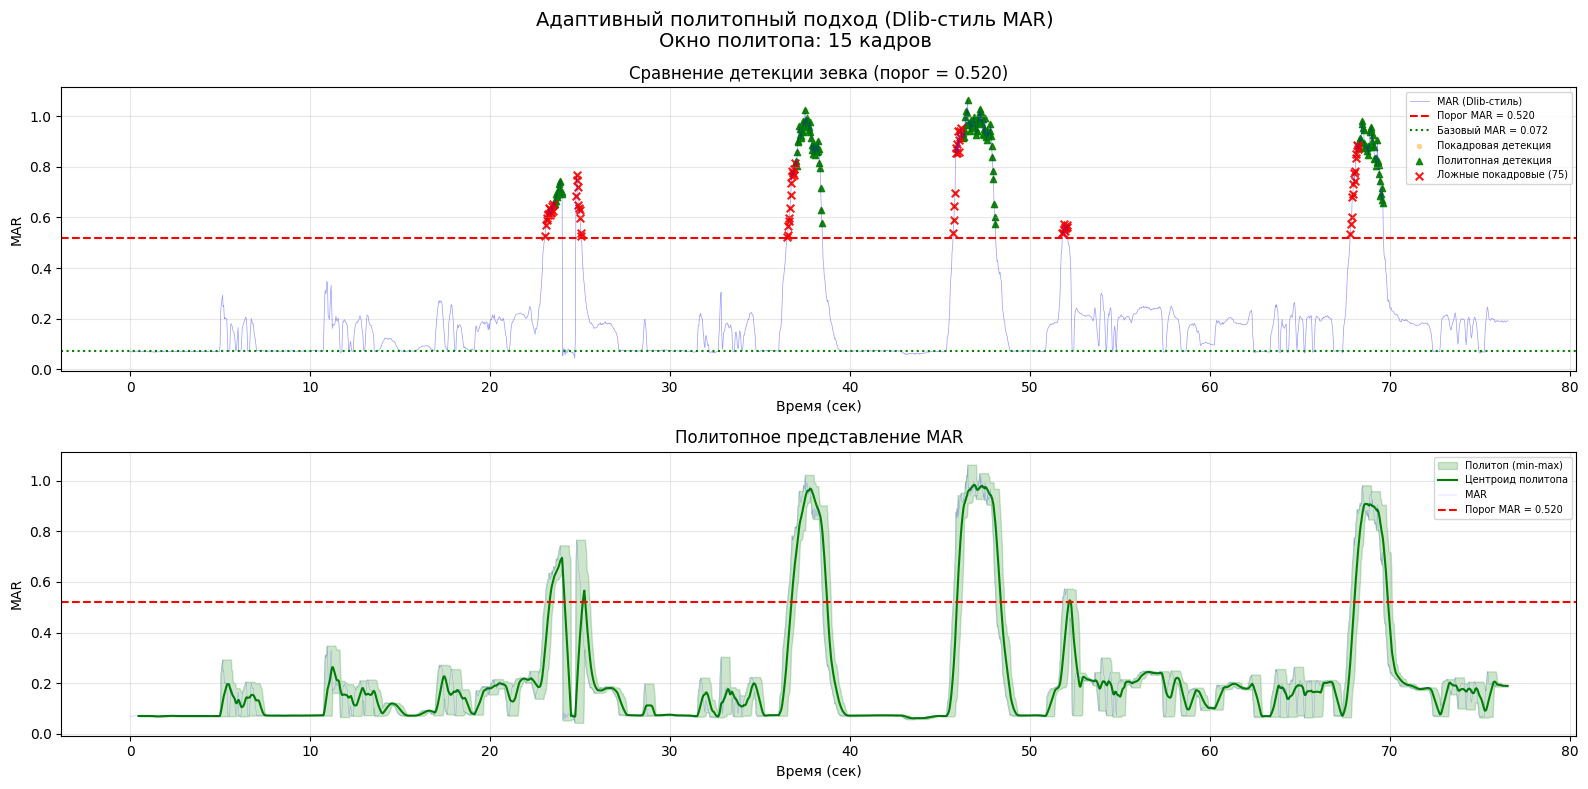


График сохранен: single_video_results\single_video_result.png

ЭТАП 5: ВЫВОДЫ
----------------------------------------

1. АДАПТИВНАЯ КАЛИБРОВКА (DLIB-СТИЛЬ MAR):

   Нейтральных кадров: 853
   Базовый MAR:  0.0716
   Базовый EAR:  0.2824

   Индивидуальные пороги:
   - Порог MAR:  0.0716 × 7.26 = 0.5201
   - Порог EAR:  0.2824 × 0.6   = 0.1694

   Базовый MAR отражает реальную анатомию губ водителя.
   У разных людей базовый MAR варьируется (0.04-0.12),
   что обеспечивает индивидуальную адаптацию порога.

2. ПОЛИТОПНЫЙ ПОДХОД:

   Покадровых срабатываний: 233
   Политопных срабатываний:  158
   Снижение:                 32.2%
   Исключено ложных кадров:  75

   Политоп отфильтровывает одиночные всплески MAR,
   сохраняя устойчивые паттерны зевка.

3. НАУЧНАЯ ЗНАЧИМОСТЬ:

   Формула MAR в стиле Dlib с тремя вертикальными замерами
   обеспечивает значения, сопоставимые с литературными данными
   (0.04-0.12 для закрытого рта). Это позволяет реализовать
   адаптивную калибровку порога з

In [10]:
def main():
    """Главная функция запуска исследования."""
    pipeline = PolytopeResearchPipeline()
    results = pipeline.run()
    return results


if __name__ == "__main__":
    results = main()

# Сравнение методов детекции зевка: 1D-политоп (одно видео)

## Методология

**Видео:** `8-FemaleGlasses.avi` (YawDD Dataset)

**Фактическое количество зевков на видео:** 4 события.

**Формула MAR:** Dlib-стиль с тремя вертикальными замерами:


**Адаптивная калибровка:** поиск нейтральных кадров (рот закрыт, глаза открыты) по всему видео. Базовый MAR — медиана нейтральных кадров. Порог MAR = базовый × K_MAR.

**Параметры:**
- K_MAR = 7.26 (рассчитан на датасете YawnDD)
- Окно политопа: 15 кадров
- Порог закрытого рта для калибровки: MAR < 0.09
- Порог открытых глаз для калибровки: EAR > 0.20

**Метрика:** сравнение на уровне событий (событие = непрерывная последовательность кадров с зевком).

## Результаты

### Калибровка

| Параметр | Значение |
|:---|:---|
| Нейтральных кадров | 853 |
| Базовый MAR | 0.0716 |
| Порог MAR | 0.5201 |

### Сравнение методов

| Метрика | Покадровый | 1D-политоп |
|:---|:---|:---|
| Срабатываний (кадров) | 233 | 158 |
| Событий | 6 | 4 |
| Ложных событий | 2 | — |
| Снижение ложных событий | — | 33.3% |

### Интерпретация

Покадровый метод обнаружил 6 событий (непрерывных последовательностей кадров с MAR выше порога). 1D-политоп подтвердил 4 из них как устойчивые зевки. Два события были отфильтрованы как кратковременные всплески MAR, не образующие устойчивого паттерна зевка.

Снижение ложных событий на 33.3% достигнуто без потери чувствительности к истинным зевкам — все 4 события, подтвержденные политопом, являются полноценными зевками.